---
title: CMMTE Comparisons
date: 02/2026
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

A notebook to compare our AR catalog with an archive of manually identified CMMTs, or cloud-mass meridional transport events, originally reported in **(cite paper)**.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import cartopy.crs as ccrs

from artools.loading_utils import *
from artools.attribute_utils import *
from artools.format_utils import *
from artools.display_utils import *

/home/jovyan/antarctic_AR_dataset/notebooks/quality_assurance


First, let's load up a csv file with count and duration information for CMMTs across all of Antarctica, for each month of each year from 1993-2022.

In [2]:
# loading up the CMMT data
cmmts = pd.read_csv('../../input_data/cmmt/cmmt_counts.csv')

In [3]:
# loading up the catalogs and doing some light preprocessing
ais_da = load_ais()

full_cat = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
landfalling_storms = full_cat[full_cat.is_landfalling]

landfalling_storms['start_date'] = landfalling_storms['data_array'].apply(add_start_date, ais_da=ais_da)
landfalling_storms['end_date'] = landfalling_storms['data_array'].apply(add_end_date, ais_da=ais_da)
landfalling_storms['landfall_duration'] = landfalling_storms['data_array'].apply(compute_duration, ais_da=ais_da)
landfalling_storms['full_duration'] = landfalling_storms['data_array'].apply(compute_duration)

## Aggregate Statistics

First, let's compare aggregate statistics across our catalog and the archive of CMMTEs. Specifically, we'll focus on comparing time series of event counts across each year.

In [4]:
yearly_cmmts = cmmts.groupby('Year')['# of Events'].sum()
yearly_cmmts = yearly_cmmts.loc[1993:2022]
yearly_ars = landfalling_storms.groupby(landfalling_storms['start_date'].dt.year).size()
yearly_ars = yearly_ars.loc[1993:2022]

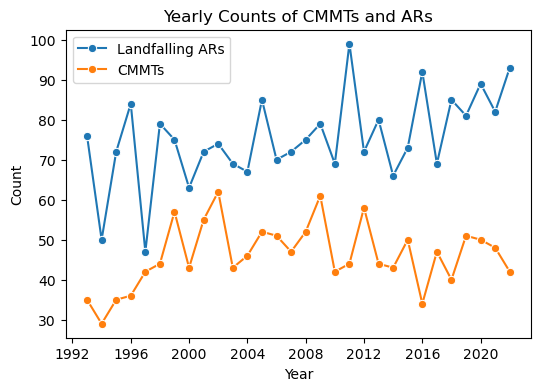

In [5]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=yearly_ars.index.astype(int), 
             y=yearly_ars.values, 
             marker='o', 
             label='Landfalling ARs')

sns.lineplot(x=yearly_cmmts.index.astype(int), 
             y=yearly_cmmts.values, 
             marker='o', 
             label='CMMTs')

plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Yearly Counts of CMMTs and ARs')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.legend();

We can also assess the degree of correlation between the two time series, first by finding the correlation between counts for each year across the two series, as well as the correlation between the first-order differenced series.

In [64]:
yearly_cmmts.corr(yearly_ars, method='spearman')

np.float64(0.06855739169271995)

In [63]:
cmmt_differenced = yearly_cmmts.diff(periods=1)
ars_differenced = yearly_ars.diff(periods=1)
ars_differenced.corr(cmmt_differenced, method='spearman')

np.float64(-0.07466377359837739)

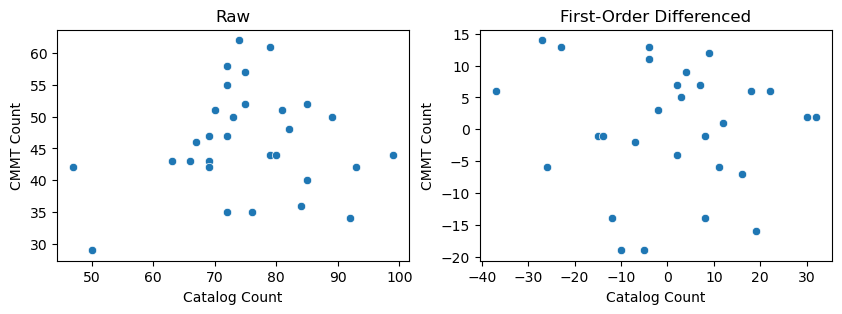

In [8]:
fig, ax = plt.subplots(ncols=2, figsize=(10,3))

ax[0].set_title('Raw')
ax[0].set_ylabel('CMMT Count')
ax[0].set_xlabel('Catalog Count')
sns.scatterplot(x=yearly_ars, y=yearly_cmmts, ax=ax[0])
ax[1].set_title('First-Order Differenced')
ax[1].set_ylabel('CMMT Count')
ax[1].set_xlabel('Catalog Count')
sns.scatterplot(x=ars_differenced, y=cmmt_differenced, ax=ax[1]);

As we can see, the correlations are pretty low (close to 0). We suspect one factor in this may the time condition on definining a CMMT event: CMMTs are only considered if they make landfall for at least 48 hours consecutively. Our catalog does not consider a similar time condition (i.e. ARs can be counted as landfalling and only make landfall for 3 hours). Another reason is also that CMMTs encompass a broader class of events than ARs, so there are likely many events that consist of meridional moisture transport yet don't meet the criteria of being an AR, as defined in the original AR catalog.

To explore this idea further, let's consider only ARs whose landfalling duration is at least 48 hours.

In [65]:
landfalling_storms_longer = landfalling_storms[landfalling_storms.landfall_duration >= 48]
yearly_cmmts = cmmts.groupby('Year')['# of Events'].sum()
yearly_cmmts = yearly_cmmts.loc[1993:2022] 
yearly_ars_longer = landfalling_storms_longer.groupby(landfalling_storms_longer['start_date'].dt.year).size()
yearly_ars_longer = yearly_ars_longer.loc[1993:2022]

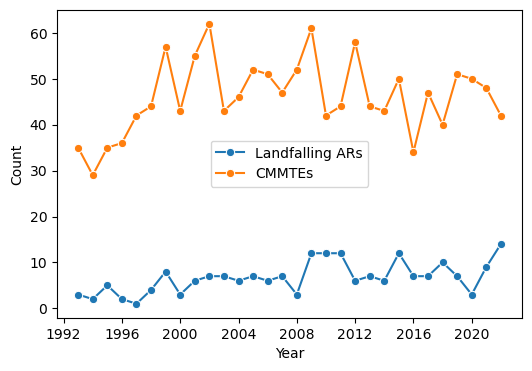

In [66]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=yearly_ars_longer.index.astype(int), 
             y=yearly_ars_longer.values, 
             marker='o', 
             label='Landfalling ARs')
sns.lineplot(x=yearly_cmmts.index.astype(int), 
             y=yearly_cmmts.values, 
             marker='o', 
             label='CMMTEs')
# Axis Labeling
plt.xlabel('Year')
plt.ylabel('Count')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend();

In [67]:
yearly_cmmts.corr(yearly_ars_longer, method='spearman')

np.float64(0.24097636088936564)

In [68]:
cmmt_differenced = yearly_cmmts.diff(periods=1)
ars_differenced_longer = yearly_ars_longer.diff(periods=1)
ars_differenced_longer.corr(cmmt_differenced, method='spearman')

np.float64(0.14418955860982358)

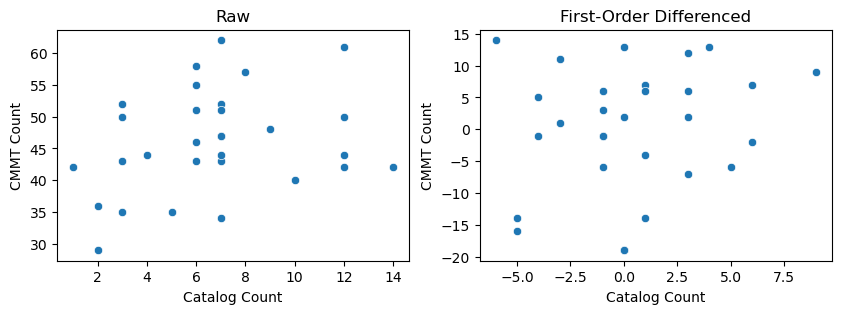

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(10,3))

ax[0].set_title('Raw')
ax[0].set_ylabel('CMMT Count')
ax[0].set_xlabel('Catalog Count')
sns.scatterplot(x=yearly_ars_longer, y=yearly_cmmts, ax=ax[0])
ax[1].set_title('First-Order Differenced')
ax[1].set_ylabel('CMMT Count')
ax[1].set_xlabel('Catalog Count')
sns.scatterplot(x=ars_differenced_longer, y=cmmt_differenced, ax=ax[1]);

The correlations are slightly higher than in the unfiltered dataset of ARs yet not high enough to be considered a strong or even moderate correlation. We notice that there are now markedly fewer ARs whose landfalling durations are greater than 48 hours than recorded CMMTs for each year. This is likely because the condition on AR landfall is now fairly stringent: CMMTs do not necessarily require the same level of extreme poleward integrated vapor transport as in the definition of an AR, and further requiring the AR to maintain this extreme level of vapor transport for 48 hours vastly restricts the event counts relative to the CMMT counts.

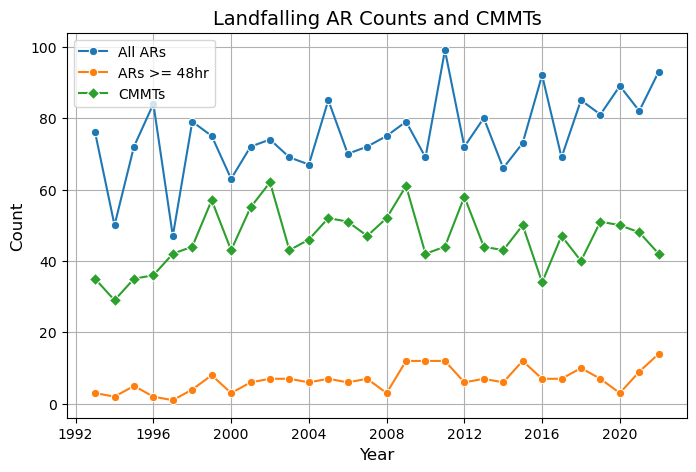

In [15]:
fig, ax = plt.subplots(ncols=1, figsize=(8,5))
sns.lineplot(x=yearly_ars.index.astype(int), 
             y=yearly_ars.values, 
             marker='o', 
             label='All ARs',
             ax=ax)
sns.lineplot(x=yearly_ars_longer.index.astype(int), 
             y=yearly_ars_longer.values, 
             marker='o', 
             label='ARs >= 48hr',
             ax=ax)
sns.lineplot(x=yearly_cmmts.index.astype(int), 
             y=yearly_cmmts.values, 
             marker='D', 
             label='CMMTs',
             ax=ax)

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid()
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Landfalling AR Counts and CMMTs', fontsize=14)
fig.savefig('../../output/plots/cmmt_yearly_comparison.png', dpi=300)

It will also be useful for us to grab some count statistics we can use to facilitate our comparison.

In [38]:
ars_mean = yearly_ars_longer.mean()
ars_mean

np.float64(6.7)

In [39]:
ars_sd = yearly_ars_longer.std()
ars_sd

np.float64(3.364623256052959)

In [40]:
cmmts_mean = yearly_cmmts.mean()
cmmts_mean

np.float64(46.1)

In [41]:
cmmts_sd = yearly_cmmts.std()
cmmts_sd

np.float64(8.061616163798286)

We also make the above clean plot, but comparing just those ARs which make landfall for at least 48 hours.

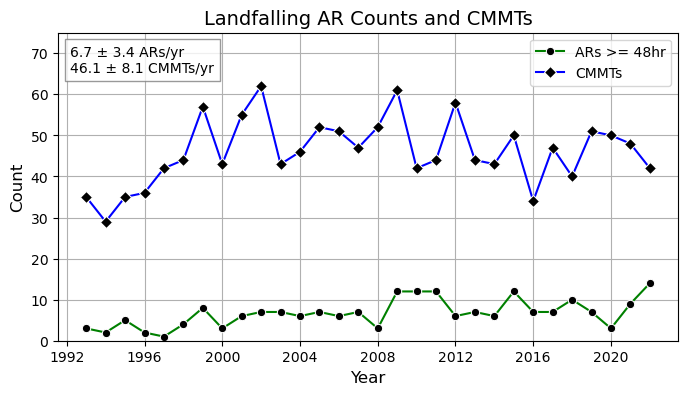

In [60]:
fig, ax = plt.subplots(ncols=1, figsize=(8,4))
sns.lineplot(x=yearly_ars_longer.index.astype(int), 
             y=yearly_ars_longer.values, 
             marker='o', 
             label='ARs >= 48hr',
             ax=ax,
             color='green',
             mfc='black')
sns.lineplot(x=yearly_cmmts.index.astype(int), 
             y=yearly_cmmts.values, 
             marker='D', 
             label='CMMTs',
             ax=ax,
             color='blue',
             mfc='black')

ax.text(0.02, 0.96,
        f'{ars_mean:.1f} ± {ars_sd:.1f} ARs/yr \n{cmmts_mean:.1f} ± {cmmts_sd:.1f} CMMTs/yr',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=10,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, pad=4))

ax.set_ylim(0, 75)

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid()
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Landfalling AR Counts and CMMTs', fontsize=14)
fig.savefig('../../output/plots/cmmt_yearly_comparison.png', dpi=300)

## Individual Event Comparisons

We also compare our products on an event-by-event basis, verifying which events in the CMMT archive are present in our catalog. Because the total CMMT archive consists of 30 years of observations, which will be quite laborious to comb through, we instead opt to compare our catalog with only those events identified between January 2009 and November 2009. Below, we show an animation of all of the landfalling ARs in our catalog. For each CMMT, we try to identify by-eye which AR is likely associated with that event, looking for ARs around the CMMT's recorded landfalling region with a time buffer of 24 hours around the actual recorded landfall times.

Region definitions can be found [here](https://amrdc.ssec.wisc.edu/projects/cmmt). We also plot the region definitions below for ease of comparison.

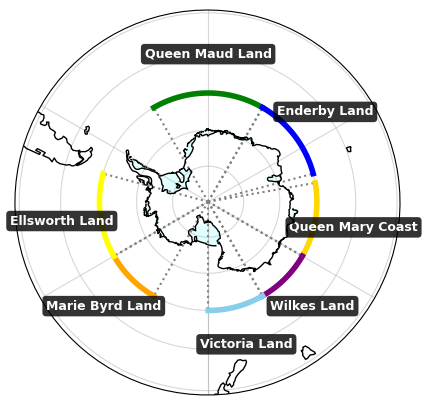

In [15]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
format_polar_axis(ax)

regions = [
    {"name": "Marie Byrd Land",  "color": "orange",  "lon_min": -150, "lon_max": -120},
    {"name": "Ellsworth Land",   "color": "yellow",  "lon_min": -120, "lon_max": -75},
    {"name": "Queen Maud Land",  "color": "green",   "lon_min": -30,  "lon_max": 30},
    {"name": "Enderby Land",     "color": "blue",    "lon_min": 30,   "lon_max": 75},
    {"name": "Queen Mary Coast", "color": "gold",    "lon_min": 80,   "lon_max": 120},
    {"name": "Wilkes Land",      "color": "purple",  "lon_min": 120,  "lon_max": 150},
    {"name": "Victoria Land",    "color": "skyblue", "lon_min": 150,  "lon_max": 180},
]

# set the outer edge for where the lines should stop (usually -60 for Antarctica)
outer_lat = -60 

for region in regions:
    # draw the radial boundary lines from the South Pole (-90) to the outer_lat
    ax.plot([region["lon_min"], region["lon_min"]], [-90, outer_lat], 
            color='gray', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree())
    ax.plot([region["lon_max"], region["lon_max"]], [-90, outer_lat], 
            color='gray', linestyle=':', linewidth=1.5, transform=ccrs.PlateCarree())
    
    # draw a thick colored arc along the outer edge to identify the region
    lons = np.linspace(region["lon_min"], region["lon_max"], 100)
    lats = np.full_like(lons, outer_lat) # Constant latitude
    
    ax.plot(lons, lats, color=region["color"], linewidth=4, transform=ccrs.PlateCarree())
    
    # add the text labels slightly outside the colored arc
    mid_lon = (region["lon_min"] + region["lon_max"]) / 2
    
    box_style = dict(boxstyle='round,pad=0.3', facecolor='black', edgecolor='none', alpha=0.8)
    
    ax.text(mid_lon, outer_lat + 10, region["name"], 
            color='white', 
            transform=ccrs.PlateCarree(), 
            ha='center', va='center', 
            fontweight='bold',
            bbox=box_style, fontsize=9)

In [16]:
storms2009 = landfalling_storms[landfalling_storms.end_date.dt.year == 2009]
stormtime = to_stormtime_format(storms2009)

In [18]:
animation = make_movie(stormtime, 'Landfalling ARs from 2009', '../../output/animations/2009_storms.mp4')

Saving animation to ../../output/animations/2009_storms.mp4...


  0%|          | 0/2920 [00:00<?, ?it/s]

In [32]:
from IPython.display import Video
Video("../../output/animations/2009_storms.mp4", embed=True, html_attributes="controls")

The full table of CMMT events, and which ARs appear to be associated with them, if any, is shown below. Out of the 54 identified CMMTs during this period, we could match 30 of them with an AR in the above movie. For the bolded values in the below table, two different CMMTs were given the same label. The discrepancy can potentially be explained by the extreme vIVT threshold required to define in an AR in the original catalog. It's possible that many of the CMMTs in this list do not have poleward vapor transport that meets the threshold required to be an AR, meaning they would be excluded from our movie entirely. Furthermore, we only count ARs which actually make landfall: it's possible that some of these CMMTs did have vIVT that exceeded the AR thresholds before landfall, but that the vIVT of the event weakened enough before landfall so the plume was not considered a landfalling AR in our movie.

:::{csv-table} Identified CMMTEs
:header-rows: 1

Dates,Location,Detected
Jan 10 3:00 UTC - Jan 13 9:00 UTC,Enderby Land,No
Jan 27 15:00 UTC - Jan 31 9:00 UTC,Enderby Land,Yes (5807)
Feb 2 6:00 UTC - Feb 6 3:00 UTC,"Skirting (45,95)",Yes (5809)
Feb 10 3:00 UTC - Feb 12 18:00 UTC,"Skirting (100,150)",Yes (5813)
Feb 18 6:00 UTC  - Feb 21 21:00 UTC,"Skirting (110,165)",**Yes (5819)**
Feb 19 12:00 UTC - Feb 21 15:00 UTC,Enderby Land,**Yes (5819)**
Feb 22 18:00 UTC - Feb 26 15:00 UTC,"Skirting (55,150)",Yes (5820)
Mar 2 6:00 UTC - Mar 8 18:00 UTC,Ellsworth,Yes (5825)
Mar 13 12:00 UTC - Mar 20 0:00 UTC,"Skirting (40, 100)",Yes (5837)
Mar 15 3:00 UTC - Mar 17 12:00 UTC,"Skirting (-15, 40)",Yes (5838)
Mar 17 18:00 UTC - Mar 21 3:00 UTC,Skirting (110-150),No
Mar 30 15:00 UTC Frame 238 – Apr 4 0:00 UTC,"Skirting (-130, -100)",No
Apr 7 6:00 UTC - Apr 12 10:00 UTC,Marie Byrd Land,No
Apr 25 22:00 UTC - Apr 28 16:00 UTC,"Skirting (100, 140)",No
Apr 26 10:00 UTC - Apr 28 15:00 UTC,Queen Maud Land,Yes (5855)
Apr 27 11:00 UTC - Apr 29 16:00 UTC,"Skirting (-140, -80)",No
Apr 29 13:00 UTC – May 3 2:00 UTC,"Skirting (130, 160)",No
May 17 9:00 UTC - May 19 9:00 UTC,"Skirting (40, 80)",Yes (5871)
May 21 10:00 UTC - May 24 3:00 UTC,Ellsworth,No
May 23 22:00 UTC - May 26 19:00 UTC,Queen Maud Land,Yes (5878)
May 29 17:00 UTC - May 31 18:00 UTC,Ellsworth, Yes (5883)
Jun 2 22:00 UTC - Jun 5 11:00 UTC,"Skirting (100, 130)",Yes (5888)
Jun 9 15:00 UTC - Jun 12 21:00 UTC,Enderby Land,No
Jun 10 7:00 UTC - Jun 12 12:00 UTC,Queen Maud Land,No
Jun 11 13:00 UTC - Jun 14 10:00 UTC,"Skirting (100, 130)",Yes (5890)
Jun 12 13:00 UTC - Jun 14 16:00 UTC,Ellsworth,No
Jun 24 3:00 UTC – Jun 27 8:00 UTC,Enderby Land,Yes (5902)
Jun 30 20:00 UTC – Jul 4 20:00 UTC,Wilkes Land,Yes (5906)
Jul 2 11:00 UTC - Jul 5 15:00 UTC,"Skirting (30, 80)",Yes (5909)
Jul 10 5:00 UTC - Jul 14 18:00 UTC,"Skirting (100, 130)",Yes (5919)
Jul 16 20:00 UTC - Jul 19 3:00 UTC,"Skirting (100, 120)",No
Jul 19 21:00 UTC Frame 214 - Jul 22 14:00 UTC,"Skirting (-130, -100)",Yes (5926)
Jul 24 17:00 UTC  - Jul 30 23:00 UTC,"Skirting (-150, -90)",No
Aug 1 2:00 UTC - Aug 3 3:00 UTC,Ellsworth,No
Aug 23 23:00 UTC - Aug 29 6:00 UTC,Ellsworth,No
Sep 2 15:00 UTC - Sep 5 8:00 UTC,Queen Mary Coast,Yes (5949)
Sep 3 9:00 UTC - Sep 5 9:00 UTC,Marie Byrd Land,No
Sep 8 22:00 UTC - Sep 12 2:00 UTC,Enderby Land,Yes (5958)
Sep 17 12:00 UTC  - Sep 21 16:00 UTC,"Skirting (-140, -80)",No
Oct 5 12:00 UTC - Oct 7 20:00 UTC,"Skirting (-20, 50)",No
Oct 6 10:00 UTC  - Oct 8 16:00 UTC,"Skirting (100, 140)",No
Oct 9 19:00 UTC - Oct 13 12:00 UTC,Enderby Land,No
Oct 14 8:00 UTC - Oct 16 10:00 UTC,"Skirting (0, 45)",Yes (5983)
Oct 17 6:00 UTC  - Oct 20 12:00 UTC,"Skirting (20, 35)",Yes (5986)
Oct 20 15:00 UTC - Oct 24 13:00 UTC,"Skirting (-135, -90)",No
Oct 23 7:00 UTC - Oct 27 12:00 UTC,Enderby Land,Yes (5988)
Oct 28 23:00 UTC - Oct 31 13:00 UTC,Wilkes Land,No
Nov 7 7:00 UTC - Nov 9 14:00 UTC,"Skirting (100, 130)",No
Nov 8 3:00 UTC - Nov 11 3:00 UTC,Queen Maud Land,No
Nov 14 5:00 UTC - Nov 16 19:00 UTC,"Skirting (110, 130)",Yes (6005)
Nov 18 6:00 UTC - Nov 20 20:00 UTC,"Skirting (-140, -90)",Yes (6006)
Nov 20 7:00 UTC - Nov 26 14:00 UTC,"Skirting (50, 120)",Yes (6012)
Nov 20 20:00 UTC - Nov 23 12:00 UTC,"Skirting (-135, -75)",Yes (6010)
Nov 28 3:00 UTC - Nov 30 8:00 UTC,"Skirting (-135, -90)", Yes (6026)
:::

Let's also check how many ARs we observed over this period as well. We'll count all ARs whose start dates (date of first landfall) are after January 1, 2009 and whose end dates (last date of landfall) are before December 1, 2009.

In [35]:
after_jan2009 = landfalling_storms.start_date.dt.date >= datetime.date(2009, 1, 1)
before_dec2009 = landfalling_storms.end_date.dt.date <= datetime.date(2009, 12, 1)

storms_to_consider = landfalling_storms[after_jan2009 & before_dec2009]

storms_to_consider.shape[0]

77

So, approximately 30 out of 77 landfalling ARs in this period can be matched with a CMMT.